Dataset Shape: (150, 5)

First 5 Rows:
Training Set: 120 samples
Testing Set: 30 samples

KNN Accuracy: 100.00%

Linear Regression MSE: 0.5961
Coefficient: 1.8340, Intercept: -6.9271

Cluster Distribution:
cluster
0    62
1    50
2    38
Name: count, dtype: int64


C:\Users\shahz\AppData\Local\Temp\ipykernel_3644\3715334659.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='species', data=df, ax=axes[0], palette='viridis')


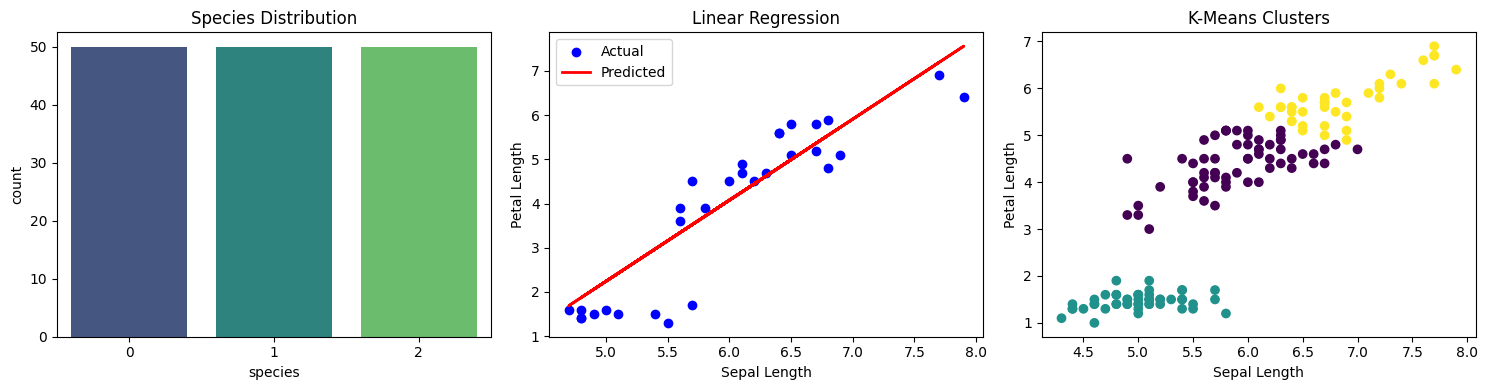

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score, mean_squared_error


# SECTION 1: Load and Explore Data

iris = load_iris()                                          ## LOADING THE DATASET
df = pd.DataFrame(iris.data, columns=iris.feature_names)    
df['species'] = iris.target

print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")                                    ## GETTING THE FIRST 5 ROWS OF DATASET
(df.head())


# SECTION 2: Train-Test Split (80/20)

X = df.drop('species', axis=1)
y = df['species']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training Set: {X_train.shape[0]} samples")
print(f"Testing Set: {X_test.shape[0]} samples")


# SECTION 3: Supervised Learning - KNN Classification

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)                               ## PASSING THE DATA KNN MODEL 
y_pred = knn.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)               ## GETTING THE ACCURACY OF THE MODEL
print(f"\nKNN Accuracy: {accuracy:.2%}")


# SECTION 4: Supervised Learning - Linear Regression

X_reg = df[['sepal length (cm)']].values
y_reg = df['petal length (cm)'].values

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

reg = LinearRegression()
reg.fit(X_train_r, y_train_r)                           ## PASSING THE DATA TO LINEAR REGRESSION 
y_pred_r = reg.predict(X_test_r)                        ## GETTING THE ACCURACY OF THE REGRESSION 

print(f"\nLinear Regression MSE: {mean_squared_error(y_test_r, y_pred_r):.4f}")
print(f"Coefficient: {reg.coef_[0]:.4f}, Intercept: {reg.intercept_:.4f}")


# SECTION 5: Unsupervised Learning - K-Means Clustering

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X)                   ### PASSING THE DATA TO KMEANS MODEL 

print("\nCluster Distribution:")
print(df['cluster'].value_counts().sort_index())


# SECTION 6: Visualizations

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Species Distribution
sns.countplot(x='species', data=df, ax=axes[0], palette='viridis')
axes[0].set_title('Species Distribution')

# Plot 2: Linear Regression
axes[1].scatter(X_test_r, y_test_r, color='blue', label='Actual')
axes[1].plot(X_test_r, y_pred_r, color='red', linewidth=2, label='Predicted')
axes[1].set_xlabel('Sepal Length')
axes[1].set_ylabel('Petal Length')
axes[1].set_title('Linear Regression')
axes[1].legend()

# Plot 3: K-Means Clusters
scatter = axes[2].scatter(df['sepal length (cm)'], df['petal length (cm)'], c=df['cluster'], cmap='viridis')
axes[2].set_xlabel('Sepal Length')
axes[2].set_ylabel('Petal Length')
axes[2].set_title('K-Means Clusters')

plt.tight_layout()
plt.show()


